In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
import seaborn as sb

from sklearn.model_selection import train_test_split

seed = 1234
np.random.seed(seed)

X_labels = np.array(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed'])

In [18]:
diabities = pd.read_csv("training_data.csv")

numpy_diabities = diabities.to_numpy()

In [5]:
pd.set_option("display.max_columns", 100)
diabities.head()

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,83148,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,1,MC,?,34,0,10,6,0,0,490,427,571,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
1,8067,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,2,?,Family/GeneralPractice,39,0,11,0,0,0,428,250,305,4,NaN,NaN,Steady,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
2,19623,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,5,?,Family/GeneralPractice,63,1,11,1,0,11,535,285,585,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30
3,77236,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,2,MC,?,39,0,22,3,0,2,482,428,585,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
4,55677,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,12,?,InternalMedicine,71,1,15,0,0,0,733,584,682,6,Norm,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30


In [6]:
data_train, data_validate = train_test_split(numpy_diabities, train_size=.88, test_size=.12, shuffle=True, random_state=seed)

X_tr = data_train[:, 1:-1]
y_tr = data_train[:, -1]

X_val = data_validate[:, 1:-1]
y_val = data_validate[:, -1]

X_tr.shape

(80598, 49)

Visualize missing data

In [16]:
def find_count_of(target):
    unknown = []
    for i in range(X_tr.shape[1]):
        unknown_in_column = X_tr[:, i] == target
        unknown_in_column = X_tr[:, i][unknown_in_column]
        unknown.append(unknown_in_column.shape[0])

    unknown = np.array(unknown)
    has_unknowns = unknown != 0
    #print(X_tr.shape)
    #print(has_unknowns)
    return X_labels[has_unknowns], unknown[has_unknowns]

In [ ]:
#print(X_labels[has_unknowns])
#print(unknown[has_unknowns])

['race' 'weight' 'payer_code' 'medical_specialty' 'diag_1' 'diag_2'
 'diag_3']
[ 1794 78101 31925 39522    16   281  1118]


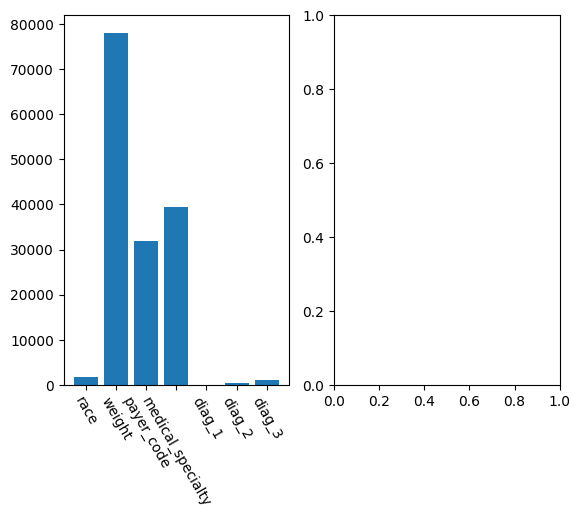

In [17]:
fig, axs = plt.subplots(1, 2)

labels_with_unknown, unknown = find_count_of("?")

axs[0].bar(labels_with_unknown, unknown)
axs[0].tick_params("x", rotation=-60)

Were probably going to have to get rid of weight, payer code, and medical specialty. It might be interesting to analze, but 

For the rest of the missing data points, I suppose we substitute in medians? 

KeyError: '49'

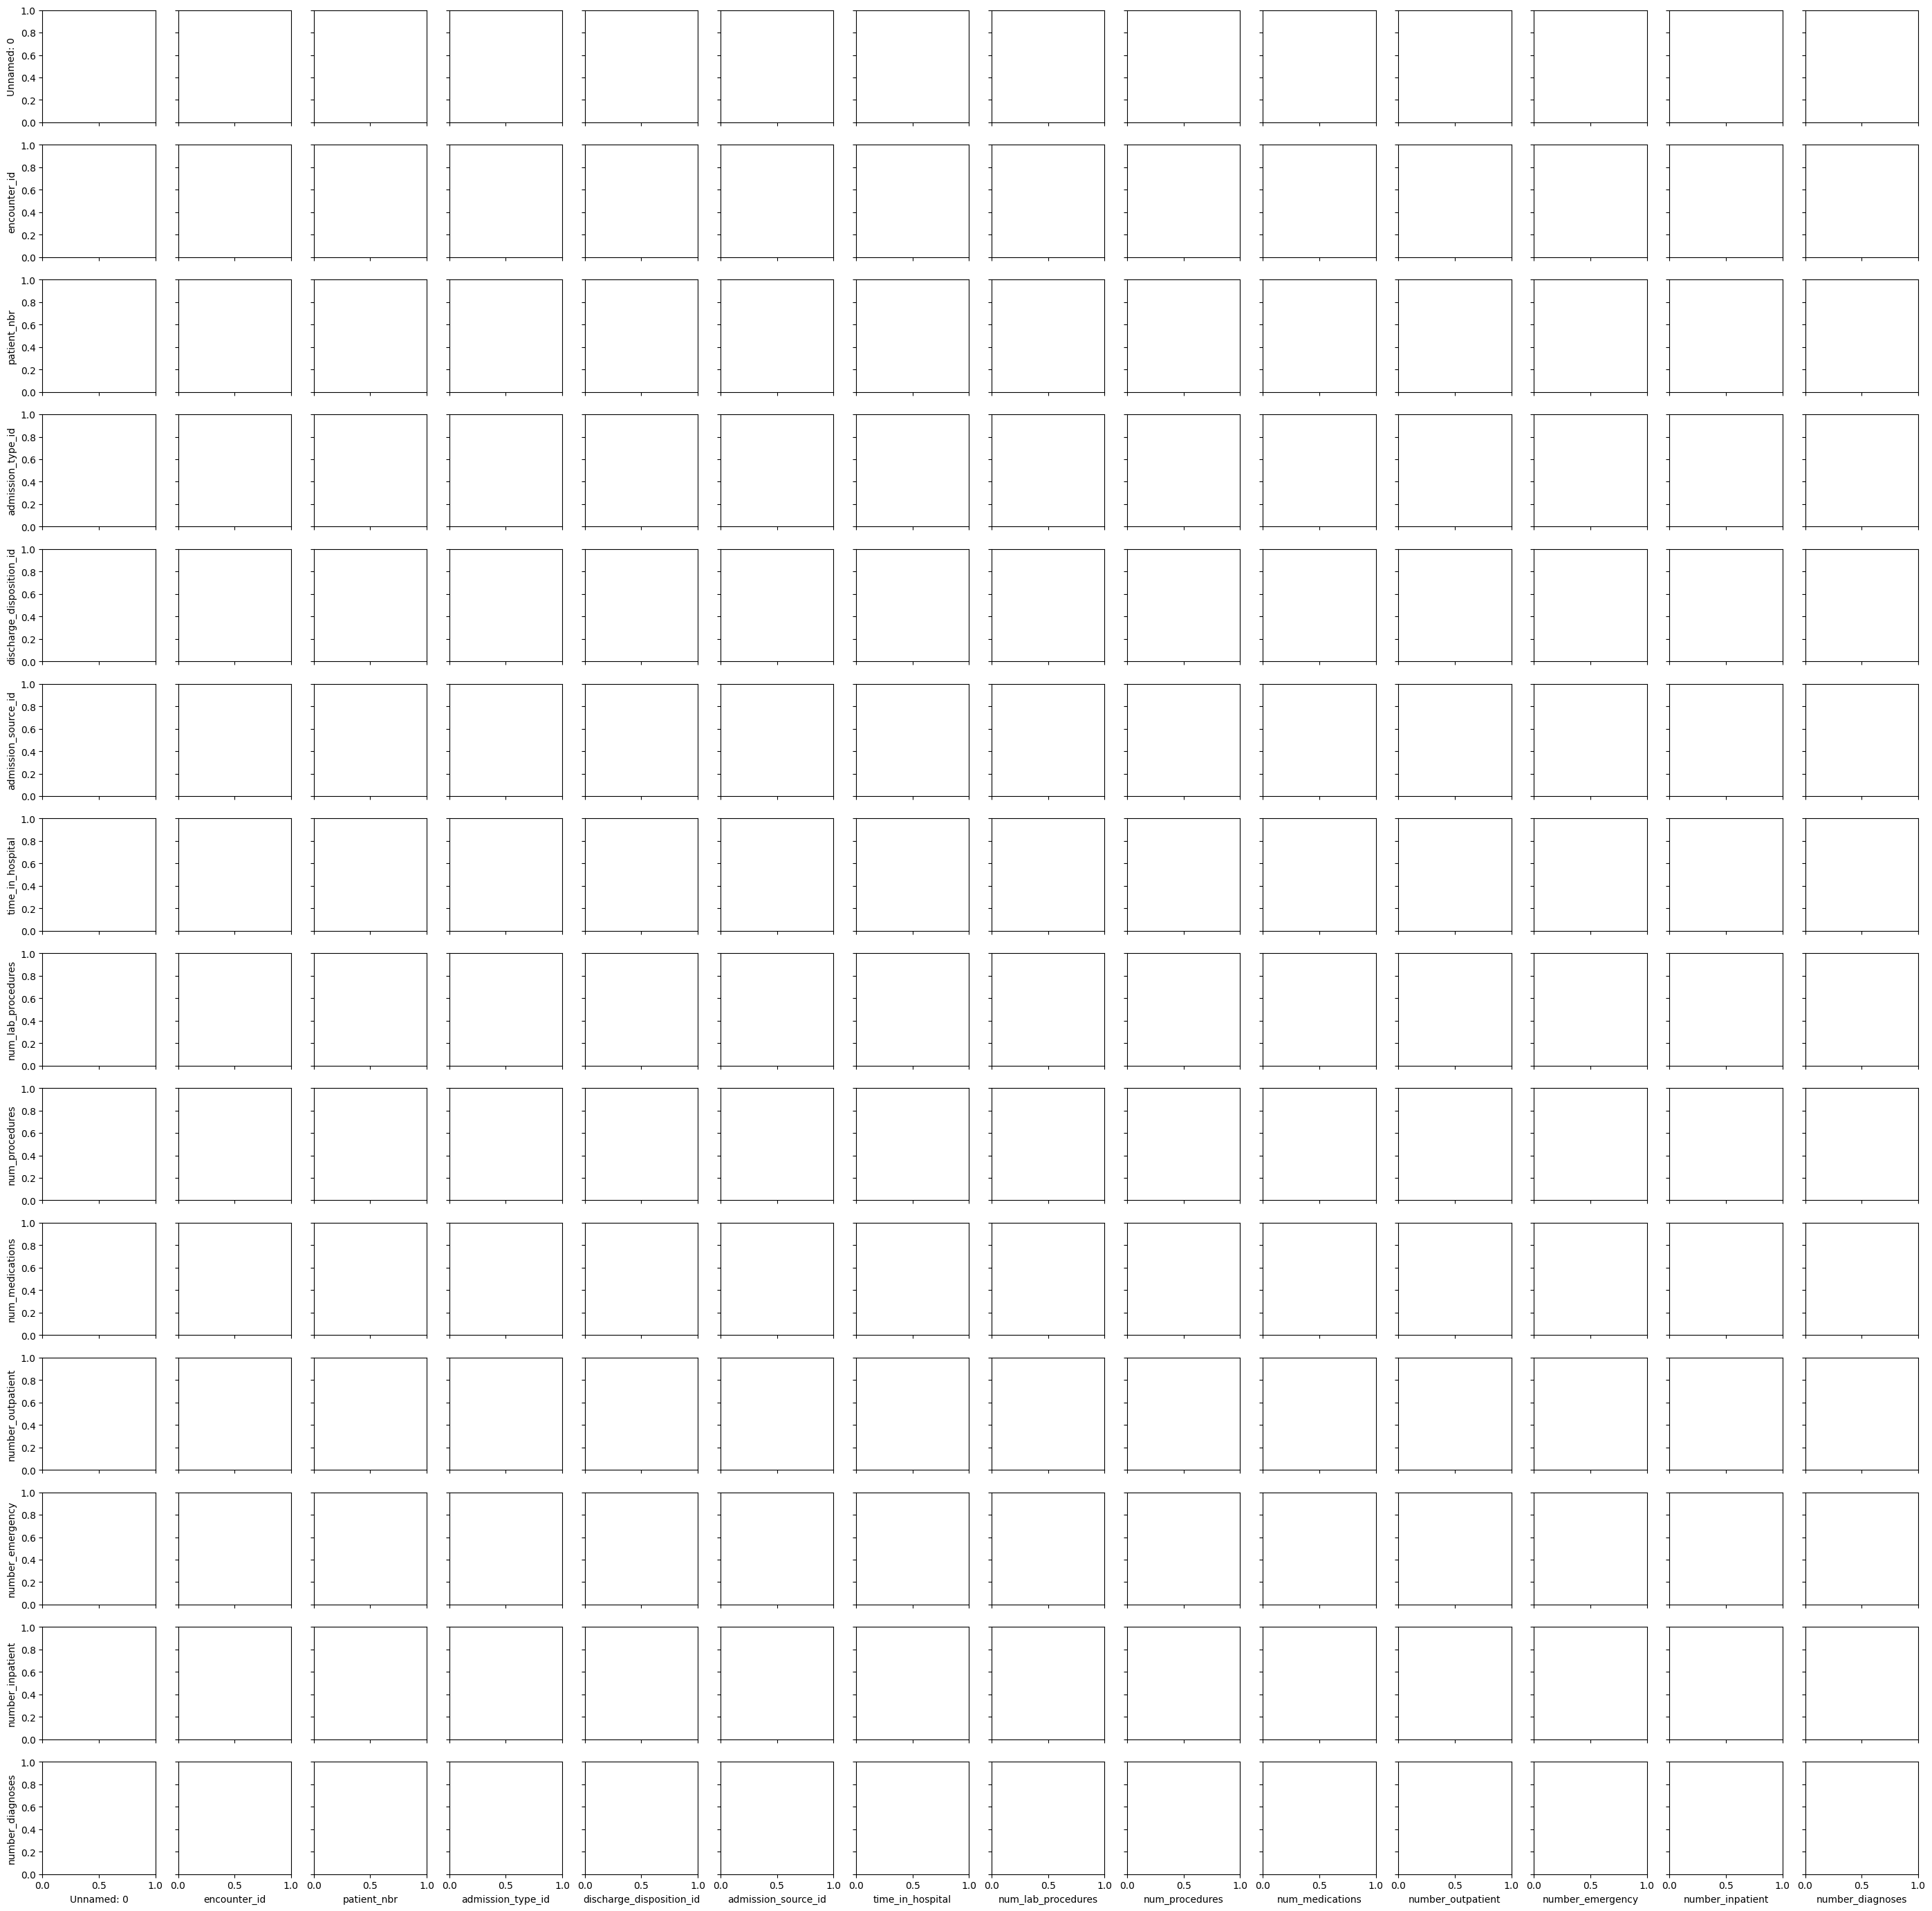

In [10]:
sb.pairplot(diabities, hue="49")

Some histograms

In [ ]:
for key in :
    

Unnamed: 0
encounter_id
patient_nbr
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed
readmitted
